# Сверточные слои: ручная реализация и сравнение производительности

В данной работе реализованы и протестированы различные подходы к созданию сверточных слоев для обработки изображений. Основной фокус - на понимание внутреннего устройства свертки через ее воспроизведение тремя различными способами:

1) Через вложенные циклы (Conv2dLoop) — для понимания базовой математики
2) Через матричное умножение (Conv2dMatrix, Conv2dMatrixV2) — для оптимизации вычислений
3) Сравнение с эталонной реализацией (torch.nn.Conv2d) — для проверки корректности

Дополнительно исследуются:
- Адаптивный подбор padding для сохранения размерности
- Пакетная нормализация (BatchNorm1d) с нуля
- Влияние функций активации на градиенты
- Применение сверточных сетей (LeNet5) на реальных данных (CIFAR-10, MNIST)

In [ ]:
import torch
import numpy as np

# Создаем входной массив из двух изображений RGB 3*3
input_images = torch.tensor(
      [[[[0,  1,  2],
         [3,  4,  5],
         [6,  7,  8]],

        [[9, 10, 11],
         [12, 13, 14],
         [15, 16, 17]],

        [[18, 19, 20],
         [21, 22, 23],
         [24, 25, 26]]],


       [[[27, 28, 29],
         [30, 31, 32],
         [33, 34, 35]],

        [[36, 37, 38],
         [39, 40, 41],
         [42, 43, 44]],

        [[45, 46, 47],
         [48, 49, 50],
         [51, 52, 53]]]])


def get_padding2d(input_images, padding=1):
    tensor_res = torch.nn.functional.pad(input_images, pad = (padding, padding, padding, padding))
    return tensor_res.float()


correct_padded_images = torch.tensor(
       [[[[0.,  0.,  0.,  0.,  0.],
          [0.,  0.,  1.,  2.,  0.],
          [0.,  3.,  4.,  5.,  0.],
          [0.,  6.,  7.,  8.,  0.],
          [0.,  0.,  0.,  0.,  0.]],

         [[0.,  0.,  0.,  0.,  0.],
          [0.,  9., 10., 11.,  0.],
          [0., 12., 13., 14.,  0.],
          [0., 15., 16., 17.,  0.],
          [0.,  0.,  0.,  0.,  0.]],

         [[0.,  0.,  0.,  0.,  0.],
          [0., 18., 19., 20.,  0.],
          [0., 21., 22., 23.,  0.],
          [0., 24., 25., 26.,  0.],
          [0.,  0.,  0.,  0.,  0.]]],


        [[[0.,  0.,  0.,  0.,  0.],
          [0., 27., 28., 29.,  0.],
          [0., 30., 31., 32.,  0.],
          [0., 33., 34., 35.,  0.],
          [0.,  0.,  0.,  0.,  0.]],

         [[0.,  0.,  0.,  0.,  0.],
          [0., 36., 37., 38.,  0.],
          [0., 39., 40., 41.,  0.],
          [0., 42., 43., 44.,  0.],
          [0.,  0.,  0.,  0.,  0.]],

         [[0.,  0.,  0.,  0.,  0.],
          [0., 45., 46., 47.,  0.],
          [0., 48., 49., 50.,  0.],
          [0., 51., 52., 53.,  0.],
          [0.,  0.,  0.,  0.,  0.]]]])

# Проверка происходит автоматически вызовом следующего кода
# (раскомментируйте для самостоятельной проверки,
#  в коде для сдачи задания должно быть закомментировано):
# print(get_padding2d(input_images).float)
# print(torch.allclose(get_padding2d(input_images), correct_padded_images))

In [ ]:
def get_padding2d(input_images, padding=1):
    tensor_res = torch.nn.functional.pad(input_images, pad = (padding, padding, padding, padding))
    return tensor_res.float()

In [ ]:
import numpy as np


def calc_out_shape(input_matrix_shape, out_channels, kernel_size, stride, padding):
    h_out = (input_matrix_shape[2] + 2 * padding - kernel_size) // stride + 1
    w_out = (input_matrix_shape[3] + 2 * padding - kernel_size) // stride + 1
    out_shape = np.array([input_matrix_shape[0], out_channels, h_out, w_out])
    return out_shape

import numpy as np
    
print(np.array_equal(
    calc_out_shape(input_matrix_shape=[2, 3, 10, 10],
                   out_channels=10,
                   kernel_size=3,
                   stride=1,
                   padding=0),
    [2, 10, 8, 8]))

print(np.array_equal(
    calc_out_shape(input_matrix_shape=[3, 2, 5, 5],
                   out_channels=5,
                   kernel_size=3,
                   stride=2,
                   padding=1),
    [3, 5, 3, 3]))

print(np.array_equal(
    calc_out_shape(input_matrix_shape=[10, 5, 15, 15],
                   out_channels=50,
                   kernel_size=5,
                   stride=5,
                   padding=2),
    [10, 50, 3, 3]))

print(np.array_equal(
    calc_out_shape(input_matrix_shape=[80, 20, 50, 50],
                   out_channels=50,
                   kernel_size=3,
                   stride=10,
                   padding=1),
    [80, 50, 5, 5]))

print(np.array_equal(
    calc_out_shape(input_matrix_shape=[100, 30, 4, 4],
                   out_channels=100,
                   kernel_size=2,
                   stride=2,
                   padding=0),
    [100, 100, 2, 2]))

print(np.array_equal(
    calc_out_shape(input_matrix_shape=[100, 30, 4, 4],
                   out_channels=100,
                   kernel_size=2,
                   stride=2,
                   padding=1),
    [100, 100, 3, 3]))

In [1]:
import torch
from abc import ABC, abstractmethod


def calc_out_shape(input_matrix_shape, out_channels, kernel_size, stride, padding):
    batch_size, channels_count, input_height, input_width = input_matrix_shape
    output_height = (input_height + 2 * padding - (kernel_size - 1) - 1) // stride + 1
    output_width = (input_width + 2 * padding - (kernel_size - 1) - 1) // stride + 1

    return batch_size, out_channels, output_height, output_width


class ABCConv2d(ABC):
    def __init__(self, in_channels, out_channels, kernel_size, stride):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride

    def set_kernel(self, kernel):
        self.kernel = kernel

    @abstractmethod
    def __call__(self, input_tensor):
        pass


class Conv2d(ABCConv2d):
    def __init__(self, in_channels, out_channels, kernel_size, stride):
        self.conv2d = torch.nn.Conv2d(in_channels, out_channels, kernel_size,
                                      stride, padding=0, bias=False)

    def set_kernel(self, kernel):
        self.conv2d.weight.data = kernel

    def __call__(self, input_tensor):
        return self.conv2d(input_tensor)


def create_and_call_conv2d_layer(conv2d_layer_class, stride, kernel, input_matrix):
    out_channels = kernel.shape[0]
    in_channels = kernel.shape[1]
    kernel_size = kernel.shape[2]

    layer = conv2d_layer_class(in_channels, out_channels, kernel_size, stride)
    layer.set_kernel(kernel)

    return layer(input_matrix)


def test_conv2d_layer(conv2d_layer_class, batch_size=2,
                      input_height=4, input_width=4, stride=2):
    kernel = torch.tensor(
                      [[[[0., 1, 0],
                         [1,  2, 1],
                         [0,  1, 0]],

                        [[1, 2, 1],
                         [0, 3, 3],
                         [0, 1, 10]],

                        [[10, 11, 12],
                         [13, 14, 15],
                         [16, 17, 18]]]])

    in_channels = kernel.shape[1]

    input_tensor = torch.arange(0, batch_size * in_channels *
                                input_height * input_width,
                                out=torch.FloatTensor()) \
        .reshape(batch_size, in_channels, input_height, input_width)

    custom_conv2d_out = create_and_call_conv2d_layer(
        conv2d_layer_class, stride, kernel, input_tensor)
    conv2d_out = create_and_call_conv2d_layer(
        Conv2d, stride, kernel, input_tensor)

    return torch.allclose(custom_conv2d_out, conv2d_out) \
             and (custom_conv2d_out.shape == conv2d_out.shape)


# Сверточный слой через циклы.
class Conv2dLoop(ABCConv2d):
    def __call__(self, input_tensor):
        batch_size, channels_count, input_height, input_width = input_tensor.shape
        out_channels = self.out_channels
        kernel_size = self.kernel_size
        stride = self.stride

        h_out = (input_height - kernel_size) // stride + 1
        w_out = (input_width - kernel_size) // stride + 1

        output = torch.zeros(batch_size, out_channels, h_out, w_out)
        
        for batch in range(batch_size):
            for channel in range(out_channels):
                for h in range(h_out):
                    for w in range(w_out):
                        h_start = h * stride
                        w_start = w * stride
                        
                        slice_ = input_tensor[batch, :, h_start : h_start + kernel_size, w_start : w_start + kernel_size]

                        kernel = self.kernel[channel]

                        value = (slice_ * kernel).sum()

                        output[batch, channel, h, w] = value
        return output
                        

# Корректность реализации определится в сравнении со стандартным слоем из pytorch.
# Проверка происходит автоматически вызовом следующего кода
# (раскомментируйте для самостоятельной проверки,
#  в коде для сдачи задания должно быть закомментировано):
# print(test_conv2d_layer(Conv2dLoop))

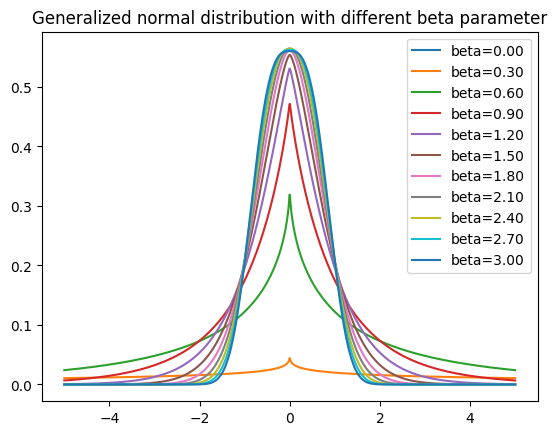

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gennorm

x = np.linspace(-5, 5, 1000)
for beta in np.linspace(0, 3, 11):
    plt.plot(x, gennorm.pdf(x, beta=beta), label='beta=%0.2f' % beta)

plt.legend(loc='upper right', prop={'size': 10})
plt.title('Generalized normal distribution with different beta parameter')
plt.show()

In [11]:
import torch
from abc import ABC, abstractmethod


def calc_out_shape(input_matrix_shape, out_channels, kernel_size, stride, padding):
    batch_size, channels_count, input_height, input_width = input_matrix_shape
    output_height = (input_height + 2 * padding - (kernel_size - 1) - 1) // stride + 1
    output_width = (input_width + 2 * padding - (kernel_size - 1) - 1) // stride + 1

    return batch_size, out_channels, output_height, output_width


class ABCConv2d(ABC):
    def __init__(self, in_channels, out_channels, kernel_size, stride):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride

    def set_kernel(self, kernel):
        self.kernel = kernel

    @abstractmethod
    def __call__(self, input_tensor):
        pass


class Conv2d(ABCConv2d):
    def __init__(self, in_channels, out_channels, kernel_size, stride):
        self.conv2d = torch.nn.Conv2d(in_channels, out_channels, kernel_size,
                                      stride, padding=0, bias=False)

    def set_kernel(self, kernel):
        self.conv2d.weight.data = kernel

    def __call__(self, input_tensor):
        return self.conv2d(input_tensor)


def create_and_call_conv2d_layer(conv2d_layer_class, stride, kernel, input_matrix):
    out_channels = kernel.shape[0]
    in_channels = kernel.shape[1]
    kernel_size = kernel.shape[2]

    layer = conv2d_layer_class(in_channels, out_channels, kernel_size, stride)
    layer.set_kernel(kernel)

    return layer(input_matrix)


def test_conv2d_layer(conv2d_layer_class, batch_size=2,
                      input_height=4, input_width=4, stride=2):
    kernel = torch.tensor(
                      [[[[0., 1, 0],
                         [1,  2, 1],
                         [0,  1, 0]],

                        [[1, 2, 1],
                         [0, 3, 3],
                         [0, 1, 10]],

                        [[10, 11, 12],
                         [13, 14, 15],
                         [16, 17, 18]]]])

    in_channels = kernel.shape[1]

    input_tensor = torch.arange(0, batch_size * in_channels *
                                input_height * input_width,
                                out=torch.FloatTensor()) \
        .reshape(batch_size, in_channels, input_height, input_width)

    custom_conv2d_out = create_and_call_conv2d_layer(
        conv2d_layer_class, stride, kernel, input_tensor)
    conv2d_out = create_and_call_conv2d_layer(
        Conv2d, stride, kernel, input_tensor)

    return torch.allclose(custom_conv2d_out, conv2d_out) \
             and (custom_conv2d_out.shape == conv2d_out.shape)


class Conv2dMatrix(ABCConv2d):
    def _unsqueeze_kernel(self, torch_input, output_height, output_width):    
        out_channels = self.out_channels
        in_channels = self.in_channels
        kernel_size = self.kernel_size
        
        input_height = torch_input.shape[2]
        input_width = torch_input.shape[3]
        
        padded_kernel = torch.zeros(out_channels, in_channels, input_height, input_width)
        
        padded_kernel[:, :, :kernel_size, :kernel_size] = self.kernel
        
        kernel_unsqueezed = padded_kernel.reshape(1, -1)
        
        return kernel_unsqueezed

    def __call__(self, torch_input):
        batch_size, out_channels, output_height, output_width\
            = calc_out_shape(
                input_matrix_shape=torch_input.shape,
                out_channels=self.kernel.shape[0],
                kernel_size=self.kernel.shape[2],
                stride=self.stride,
                padding=0)

        kernel_unsqueezed = self._unsqueeze_kernel(torch_input, output_height, output_width)
        result = kernel_unsqueezed @ torch_input.view((batch_size, -1)).permute(1, 0)
        return result.permute(1, 0).view((batch_size, self.out_channels,
                                          output_height, output_width))

# Проверка происходит автоматически вызовом следующего кода
# (раскомментируйте для самостоятельной проверки,
#  в коде для сдачи задания должно быть закомментировано):
# print(test_conv2d_layer(Conv2dMatrix))

In [ ]:
def _unsqueeze_kernel(self, torch_input, output_height, output_width):
        m = nn.ZeroPad2d((0,1,0,1))
        kernel_unsqueezed = m(self.kernel)
        kernel_unsqueezed = kernel_unsqueezed.reshape(1,-1)
        return kernel_unsqueezed

In [13]:
import torch
from abc import ABC, abstractmethod


def calc_out_shape(input_matrix_shape, out_channels, kernel_size, stride, padding):
    batch_size, channels_count, input_height, input_width = input_matrix_shape
    output_height = (input_height + 2 * padding - (kernel_size - 1) - 1) // stride + 1
    output_width = (input_width + 2 * padding - (kernel_size - 1) - 1) // stride + 1

    return batch_size, out_channels, output_height, output_width


class ABCConv2d(ABC):
    def __init__(self, in_channels, out_channels, kernel_size, stride):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride

    def set_kernel(self, kernel):
        self.kernel = kernel

    @abstractmethod
    def __call__(self, input_tensor):
        pass


def create_and_call_conv2d_layer(conv2d_layer_class, stride, kernel, input_matrix):
    out_channels = kernel.shape[0]
    in_channels = kernel.shape[1]
    kernel_size = kernel.shape[2]

    layer = conv2d_layer_class(in_channels, out_channels, kernel_size, stride)
    layer.set_kernel(kernel)

    return layer(input_matrix)


class Conv2d(ABCConv2d):
    def __init__(self, in_channels, out_channels, kernel_size, stride):
        self.conv2d = torch.nn.Conv2d(in_channels, out_channels, kernel_size,
                                      stride, padding=0, bias=False)

    def set_kernel(self, kernel):
        self.conv2d.weight.data = kernel

    def __call__(self, input_tensor):
        return self.conv2d(input_tensor)


def test_conv2d_layer(conv2d_layer_class, batch_size=2,
                      input_height=4, input_width=4, stride=2):
    kernel = torch.tensor(
                      [[[[0., 1, 0],
                         [1,  2, 1],
                         [0,  1, 0]],

                        [[1, 2, 1],
                         [0, 3, 3],
                         [0, 1, 10]],

                        [[10, 11, 12],
                         [13, 14, 15],
                         [16, 17, 18]]]])

    in_channels = kernel.shape[1]

    input_tensor = torch.arange(0, batch_size * in_channels *
                                input_height * input_width,
                                out=torch.FloatTensor()) \
        .reshape(batch_size, in_channels, input_height, input_width)

    custom_conv2d_out = create_and_call_conv2d_layer(
        conv2d_layer_class, stride, kernel, input_tensor)
    conv2d_out = create_and_call_conv2d_layer(
        Conv2d, stride, kernel, input_tensor)

    return torch.allclose(custom_conv2d_out, conv2d_out) \
             and (custom_conv2d_out.shape == conv2d_out.shape)


class Conv2dMatrixV2(ABCConv2d):
    def _convert_kernel(self):
        in_channels = self.in_channels
        out_channels = self.out_channels
        kernel_size = self.kernel_size
        stride = self.stride

        converted_kernel = torch.zeros(out_channels, kernel_size * kernel_size * in_channels)
        
        for out_channel_x in range(out_channels):
            kernel_row = []
            for in_channels_y in range(in_channels):

                kernel_slice = self.kernel[out_channel_x, in_channels_y]
                kernel_row.append(kernel_slice.flatten())
                
            converted_kernel[out_channel_x] = torch.cat(kernel_row)
        
        return converted_kernel

    def _convert_input(self, torch_input, output_height, output_width):
        patches = F.unfold(
        torch_input,
        kernel_size=self.kernel_size,
        stride=self.stride
        )
        converted = patches.permute(1, 0, 2).reshape(patches.shape[1], -1)
        
        return converted

    def __call__(self, torch_input):
        batch_size, out_channels, output_height, output_width\
            = calc_out_shape(
                input_matrix_shape=torch_input.shape,
                out_channels=self.kernel.shape[0],
                kernel_size=self.kernel.shape[2],
                stride=self.stride,
                padding=0)

        converted_kernel = self._convert_kernel()
        converted_input = self._convert_input(torch_input, output_height, output_width)

        conv2d_out_alternative_matrix_v2 = converted_kernel @ converted_input
        return conv2d_out_alternative_matrix_v2.transpose(1,0).view(torch_input.shape[0],
                                                     self.out_channels, 
                                                     output_height,
                                                     output_width)

# Проверка происходит автоматически вызовом следующего кода
# (раскомментируйте для самостоятельной проверки,
#  в коде для сдачи задания должно быть закомментировано):
# print(test_conv2d_layer(Conv2dMatrixV2))

TypeError: reshape(): argument 'shape' (position 2) must be tuple of ints, not int

In [43]:
import torch

N = 4
C = 3
C_out = 10
H = 8
W = 16

x = torch.ones((N, C, H, W))

# torch.Size([4, 10, 8, 16])
out1 = torch.nn.Conv2d(C, C_out, kernel_size=(3, 3), padding=1)(x)
# print(out1.shape) # для самопроверки

# torch.Size([4, 10, 8, 16])
out2 = torch.nn.Conv2d(C, C_out, kernel_size=(5, 5), padding=2)(x)
# print(out2.shape) # для самопроверки

# torch.Size([4, 10, 8, 16])
out3 = torch.nn.Conv2d(C, C_out, kernel_size=(7, 7), padding=3)(x)
#print(out3.shape) # для самопроверки

# torch.Size([4, 10, 8, 16])
out4 = torch.nn.Conv2d(C, C_out, kernel_size=(9, 9), padding=4)(x)
#print(out4.shape) # для самопроверки

# torch.Size([4, 10, 8, 16]) ?????????????????????
out5 = torch.nn.Conv2d(C, C_out, kernel_size=(3, 5), padding=(1, 2))(x)
# print(out5.shape) # для самопроверки

# torch.Size([4, 10, 22, 30])
out6 = torch.nn.Conv2d(C, C_out, kernel_size=(3, 3), padding=8)(x)
# print(out6.shape) # для самопроверки

# torch.Size([4, 10, 7, 15])
out7 = torch.nn.Conv2d(C, C_out, kernel_size=(4, 4), padding=1)(x)
# print(out7.shape) # для самопроверки

# torch.Size([4, 10, 9, 17])
out8 = torch.nn.Conv2d(C, C_out, kernel_size=(2, 2), padding=1)(x)
# print(out8.shape) # для самопроверки

torch.Size([4, 10, 8, 16])


# LeNet и его модификация

In [65]:
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

In [46]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [47]:
import torchvision.datasets

In [51]:
MNIST_train = torchvision.datasets.MNIST('./', download = True, train = True)
MNIST_test = torchvision.datasets.MNIST('./', download = True, train = False)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:03<00:00, 2.82MB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 189kB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.57MB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 5.45MB/s]


In [59]:
X_train = MNIST_train.train_data
y_train = MNIST_train.train_labels
X_test = MNIST_train.test_data
y_test = MNIST_train.test_labels

/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")
/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/torchvision/datasets/mnist.py:81: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


In [58]:
len(y_train), len(y_test)

(60000, 60000)

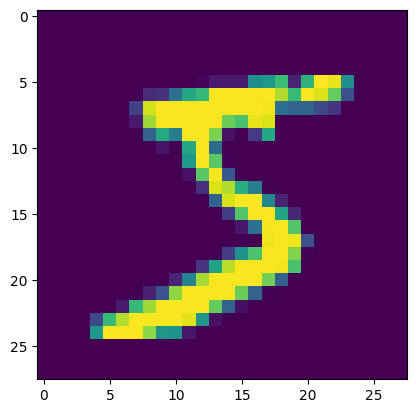

tensor(5)


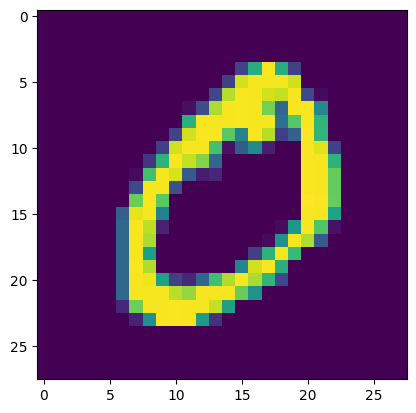

tensor(5)


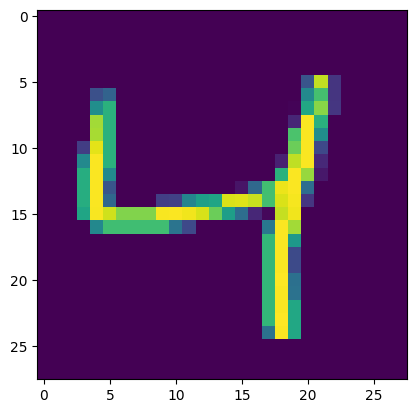

tensor(5)


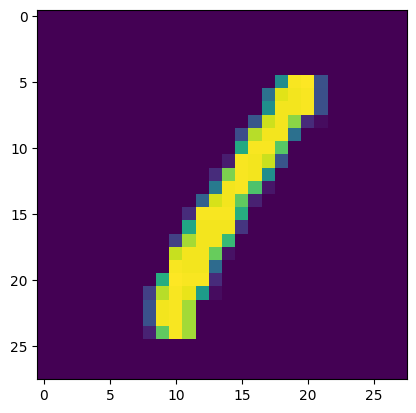

tensor(5)


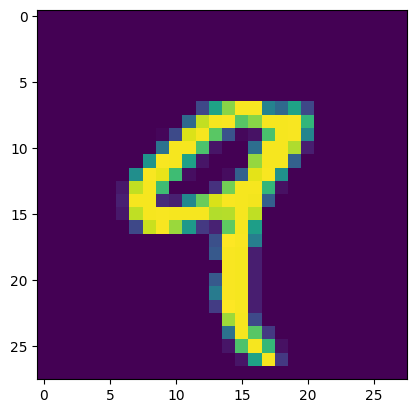

tensor(5)


In [70]:
for x in range(5):
    plt.imshow(X_train[x, :, :])
    plt.show()
    print(y_train[0])

In [79]:
X_train = X_train.unsqueeze(1).float()
X_test = X_test.unsqueeze(1).float()

In [80]:
class LeNet5(torch.nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.act1 = torch.nn.ReLU()
        self.pool1 = torch.nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv2 = torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding=0)
        self.act2 = torch.nn.ReLU()
        self.pool2 = torch.nn.AvgPool2d(kernel_size=2, stride=2)

        self.fc1 = torch.nn.Linear(5 * 5 * 16, 120)
        self.act3 = torch.nn.ReLU()

        self.fc2 = torch.nn.Linear(120, 84)
        self.act4 = torch.nn.Tanh()
        
        self.fc3 = torch.nn.Linear(84, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))
        
        x = self.fc1(x)
        x = self.act3(x)

        x = self.fc2(x)
        x = self.act4(x)

        x = self.fc3(x)

        return x

lenet5 = LeNet5()

In [76]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
lenet5 = lenet5.to(device)

In [83]:
loss = torch.nn.CrossEntropyLoss()
optim = torch.optim.Adam(lenet5.parameters(), lr=1.0e-3)

In [84]:
batch_size = 100

X_test = X_test.to(device)
y_test = y_test.to(device)

test_loss_history = []
test_accuracy_history = []

for epoch in range(1000):
    order = np.random.permutation(len(X_train))
    for x in range(0, len(X_train), batch_size):
        optim.zero_grad()

        batch_ind = order[x : x + batch_size]

        X_batch = X_train[batch_ind].to(device)
        y_batch = y_train[batch_ind].to(device)

        preds = lenet5.forward(X_batch)

        loss_value = loss(preds, y_batch)
        loss_value.backward()
        
        optim.step()

    test_preds = lenet5.forward(X_test)
    test_loss_history.append(loss(test_preds, y_test).data.cpu())
    
    accuracy = (test_preds.argmax(dim=1) == y_test).float().mean().data.cpu()
    test_accuracy_history.append(accuracy)
    
    print(accuracy)

tensor(0.9790)
tensor(0.9883)
tensor(0.9926)
tensor(0.9898)
tensor(0.9932)
tensor(0.9923)
tensor(0.9942)
tensor(0.9959)
tensor(0.9961)
tensor(0.9955)


KeyboardInterrupt: 

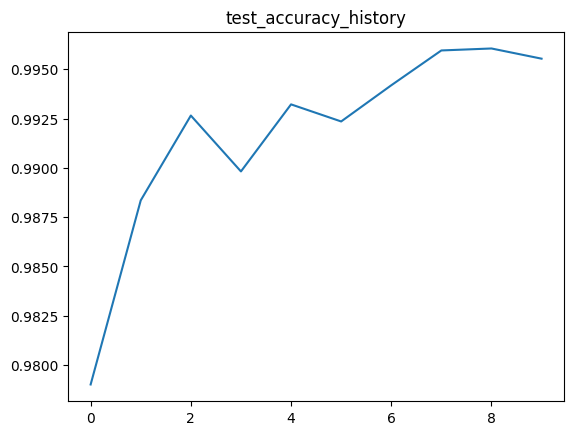

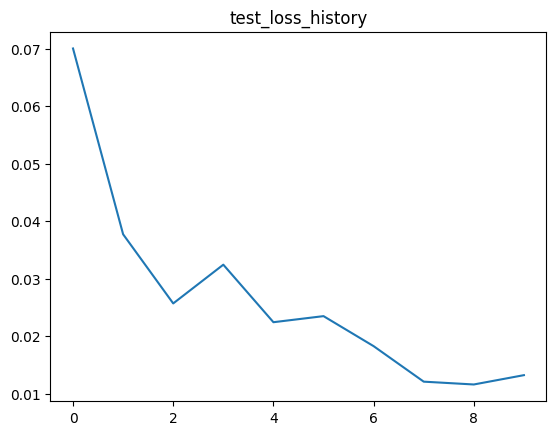

In [90]:
plt.plot(test_accuracy_history)
plt.title('test_accuracy_history')
plt.show()

plt.plot(test_loss_history)
plt.title('test_loss_history')
plt.show()

In [95]:
test_accuracy_history_arr = np.array(test_accuracy_history)

In [97]:
test_accuracy_history_arr.max()

np.float32(0.99605)

In [102]:
import numpy as np
import torch
import torch.nn as nn

def custom_batch_norm1d(input_tensor, eps):
    betta = 0
    gamma = 1
    x_row, y_feaut = input_tensor.shape

    normed_tensor = torch.zeros_like(input_tensor)
    
    for y in range(y_feaut):
        for x in range(x_row):
            new_num = (input_tensor[x, y] - input_tensor[:, y].mean()) / torch.sqrt((input_tensor[:, y].std(unbiased=False)) ** 2 + eps)
            normed_tensor[x, y] = new_num
    
    return normed_tensor

input_tensor = torch.Tensor([[0.0, 0, 1, 0, 2], [0, 1, 1, 0, 10]])
batch_norm = nn.BatchNorm1d(input_tensor.shape[1], affine=False)

# Проверка происходит автоматически вызовом следующего кода
# (раскомментируйте для самостоятельной проверки,
#  в коде для сдачи задания должно быть закомментировано):
# import numpy as np
# all_correct = True
# for eps_power in range(10):
#     eps = np.power(10., -eps_power)
#     batch_norm.eps = eps
#     batch_norm_out = batch_norm(input_tensor)
#     custom_batch_norm_out = custom_batch_norm1d(input_tensor, eps)

#     all_correct &= torch.allclose(batch_norm_out, custom_batch_norm_out)
#     all_correct &= batch_norm_out.shape == custom_batch_norm_out.shape
# print(all_correct)

True


In [112]:
import torch
import torch.nn as nn

input_size = 7
batch_size = 5
input_tensor = torch.randn(batch_size, input_size, dtype=torch.float)

eps = 1e-3

def custom_batch_norm1d(input_tensor, weight, bias, eps):
    x_row, y_feat = input_tensor.shape
    
    normed_tensor = torch.zeros_like(input_tensor)

    for y in range(y_feat):
        for x in range(x_row):
            num_val = (input_tensor[x, y] - input_tensor[:, y].mean()) / torch.sqrt((input_tensor[:, y].std(unbiased=False)) ** 2 + eps)
            normed_tensor[x, y] = num_val * weight[y] + bias[y]
    
    return normed_tensor

# Проверка происходит автоматически вызовом следующего кода
# (раскомментируйте для самостоятельной проверки,
#  в коде для сдачи задания должно быть закомментировано):
batch_norm = nn.BatchNorm1d(input_size, eps=eps)
batch_norm.bias.data = torch.randn(input_size, dtype=torch.float)
batch_norm.weight.data = torch.randn(input_size, dtype=torch.float)
batch_norm_out = batch_norm(input_tensor)
custom_batch_norm_out = custom_batch_norm1d(input_tensor, batch_norm.weight.data, batch_norm.bias.data, eps)
print(torch.allclose(batch_norm_out, custom_batch_norm_out, 1e-3) \
      and batch_norm_out.shape == custom_batch_norm_out.shape)

True


In [130]:
import torch
import torch.nn as nn

input_size = 3
batch_size = 5
eps = 1e-1

class CustomBatchNorm1d:
    def __init__(self, weight, bias, eps, momentum):
        self.weight = weight
        self.bias = bias
        self.eps = eps
        self.momentum = momentum
        self.running_mean = torch.zeros_like(weight)
        self.running_val = torch.ones_like(weight)
        self.training = True

    def __call__(self, input_tensor):
        weight = self.weight
        bias = self.bias
        eps = self.eps
        momentum = self.momentum
        
        x_row, y_feat = input_tensor.shape
        
        normed_tensor = torch.zeros_like(input_tensor)

        for y in range(y_feat):
            if self.training:
                mean = input_tensor[:, y].mean()
                biased_var = input_tensor[:, y].var(unbiased=False)

                unbiased_var = input_tensor[:, y].var(unbiased=True)

                self.running_mean[y] = momentum * self.running_mean[y] + (1 - momentum) * mean
                self.running_val[y] = momentum * self.running_val[y] + (1 - momentum) * unbiased_var

                current_var = biased_var
                current_mean = mean

            else:
                current_mean = self.running_mean[y]
                current_var = self.running_val[y]
            for x in range(x_row):
                
                num_val = (input_tensor[x, y] - current_mean) / torch.sqrt(current_var + eps)
                normed_tensor[x, y] = num_val * weight[y] + bias[y]
        
        return normed_tensor

    def eval(self):
        self.training = False


batch_norm = nn.BatchNorm1d(input_size, eps=eps)
batch_norm.bias.data = torch.randn(input_size, dtype=torch.float)
batch_norm.weight.data = torch.randn(input_size, dtype=torch.float)
batch_norm.momentum = 0.5

custom_batch_norm1d = CustomBatchNorm1d(batch_norm.weight.data,
                                        batch_norm.bias.data, eps, batch_norm.momentum)

# Проверка происходит автоматически вызовом следующего кода
# (раскомментируйте для самостоятельной проверки,
#  в коде для сдачи задания должно быть закомментировано):
all_correct = True

for i in range(8):
    torch_input = torch.randn(batch_size, input_size, dtype=torch.float)
    norm_output = batch_norm(torch_input)
    custom_output = custom_batch_norm1d(torch_input)
    all_correct &= torch.allclose(norm_output, custom_output, atol=1e-04) \
        and norm_output.shape == custom_output.shape

batch_norm.eval()
custom_batch_norm1d.eval()

for i in range(8):
    torch_input = torch.randn(batch_size, input_size, dtype=torch.float)
    norm_output = batch_norm(torch_input)
    custom_output = custom_batch_norm1d(torch_input)
    all_correct &= torch.allclose(norm_output, custom_output, atol=1e-04) \
        and norm_output.shape == custom_output.shape
print(all_correct)

True


## Играемся с функциями активации

In [141]:
import torch
import numpy as np

seed = int(input())
np.random.seed(seed)
torch.manual_seed(seed)

NUM_EXP = 200

class SimpleNet(torch.nn.Module):
    def __init__(self, activation):
        super().__init__()

        self.activation = activation
        self.fc1 = torch.nn.Linear(1, 1, bias = False)
        self.fc1.weight.data.fill_(1.)
        self.fc2 = torch.nn.Linear(1, 1, bias = False)
        self.fc2.weight.data.fill_(1.)
        self.fc3 = torch.nn.Linear(1, 1, bias = False)
        self.fc3.weight.data.fill_(1.)

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.activation(self.fc3(x))
        return x

    def get_fc1_grad_abs_value(self): ## что это за функция и что она делает 
        return torch.abs(self.fc1.weight.grad)

def get_fc1_grad_abs_value(net, x): #что делает эта функция 
    output = net.forward(x)
    output.backward()
    fc1_grad = net.get_fc1_grad_abs_value().item()
    net.zero_grad()
    return fc1_grad

activation_dict = {'ELU' : torch.nn.ELU(), 'Hardtanh' : torch.nn.Hardtanh(), 'LeakyReLU' : torch.nn.LeakyReLU(), 
              'LogSigmoid' : torch.nn.LogSigmoid(), 'PReLU' : torch.nn.PReLU(), 'ReLU' : torch.nn.ReLU(), 
              'ReLU6' : torch.nn.ReLU6(), 'RReLU' : torch.nn.RReLU(), 'SELU' : torch.nn.SELU(), 
              'CELU' : torch.nn.CELU(), 'Sigmoid' : torch.nn.Sigmoid(), 'Softplus' : torch.nn.Softplus(), 
              'Softshrink' : torch.nn.Softshrink(), 'Softsign' : torch.nn.Softsign(), 'Tanh' : torch.nn.Tanh(), 
              'Tanhshrink' : torch.nn.Tanhshrink(), 'Hardshrink' : torch.nn.Hardshrink()}
for x in activation_dict:
    activation = activation_dict[x]
    net = SimpleNet(activation = activation)

    fc1_grads = []
    for x in torch.randn((NUM_EXP, 1)):
        fc1_grads.append(get_fc1_grad_abs_value(net, x))

    print(activation, np.mean(fc1_grads), sep=' : ')

 20


ELU(alpha=1.0) : 0.45210774241015317
Hardtanh(min_val=-1.0, max_val=1.0) : 0.3226382967759855
LeakyReLU(negative_slope=0.01) : 0.3982032372882566
LogSigmoid() : 0.2395466901024338
PReLU(num_parameters=1) : 0.40741675882622075
ReLU() : 0.41251393426849975
ReLU6() : 0.3635738933889661
RReLU(lower=0.125, upper=0.3333333333333333) : 0.4663023960256942
SELU() : 0.6010886726435274
CELU(alpha=1.0) : 0.39137442447128706
Sigmoid() : 0.007179149592120666
Softplus(beta=1.0, threshold=20.0) : 0.23222524366108702
Softshrink(0.5) : 0.272448747754097
Softsign() : 0.06466205934993922
Tanh() : 0.1585674277949147
Tanhshrink() : 0.05386547190592182
Hardshrink(0.5) : 0.730696764588356


In [142]:
import math

def ReLU(x):
    return max(0, x)

def dReLU(x):
    if x > 0:
        return 1
    return 0

# Tanh activation
t1 =round((1 - math.tanh(math.tanh(math.tanh(math.tanh(100)))) ** 2) * (1 - math.tanh(math.tanh(math.tanh(100))) ** 2) 
          * (1 - math.tanh(math.tanh(100)) ** 2) * (1 - math.tanh(100) ** 2) * 100, 3)
t2 = round((1 - math.tanh(math.tanh(math.tanh(math.tanh(100)))) ** 2) * (1 - math.tanh(math.tanh(math.tanh(100))) ** 2) 
           * (1 - math.tanh(math.tanh(100)) ** 2) * math.tanh(100), 3)
t3 = round((1 - math.tanh(math.tanh(math.tanh(math.tanh(100)))) ** 2) * (1 - math.tanh(math.tanh(math.tanh(100))) ** 2)
      * math.tanh(math.tanh(100)), 3)
t4 = round((1 - math.tanh(math.tanh(math.tanh(math.tanh(100)))) ** 2) * math.tanh(math.tanh(math.tanh(100))), 3)
# ReLU activation 
r1 = round(dReLU(ReLU(ReLU(ReLU(100)))) * dReLU(ReLU(ReLU(100))) * dReLU(ReLU(100)) * dReLU(100) * 100, 3)
r2 = round(dReLU(ReLU(ReLU(ReLU(100)))) * dReLU(ReLU(ReLU(100))) * dReLU(ReLU(100)) * ReLU(100), 3)
r3 = round(dReLU(ReLU(ReLU(ReLU(100)))) * dReLU(ReLU(ReLU(100))) * ReLU(ReLU(100)), 3)
r4 = round(dReLU(ReLU(ReLU(ReLU(100)))) * ReLU(ReLU(ReLU(100))), 3)
answer1, answer2 = [t1, t2, t3, t4], [r1, r2, r3, r4]

print(answer1, answer2, sep=',')

[0.0, 0.168, 0.304, 0.436],[100, 100, 100, 100]


# Нейросеть с 10 классами

In [5]:
import torch
import numpy as np
import random

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [6]:
import torchvision.datasets

In [7]:
CIFAR_train = torchvision.datasets.CIFAR10('./', download=True, train=True)
CIFAR_test = torchvision.datasets.CIFAR10('./', download=True, train=False)

In [8]:
X_train = torch.FloatTensor(CIFAR_train.data)
X_test = torch.FloatTensor(CIFAR_test.data)
y_train = torch.LongTensor(CIFAR_train.targets)
y_test = torch.LongTensor(CIFAR_test.targets)

In [21]:
len(y_train), len(y_test), len(X_train), len(X_test)

(50000, 10000, 50000, 10000)

In [10]:
X_train.min(), X_test.max()

(tensor(0.), tensor(255.))

In [11]:
X_train /= 255.
X_test /= 255.

In [12]:
CIFAR_train.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

tensor(6) tensor(9) tensor(9) tensor(4) tensor(1) tensor(1) tensor(2) tensor(7) tensor(8) tensor(3) tensor(4) tensor(7) tensor(7) tensor(2) tensor(9) tensor(9) tensor(9) tensor(3) tensor(2) tensor(6) 

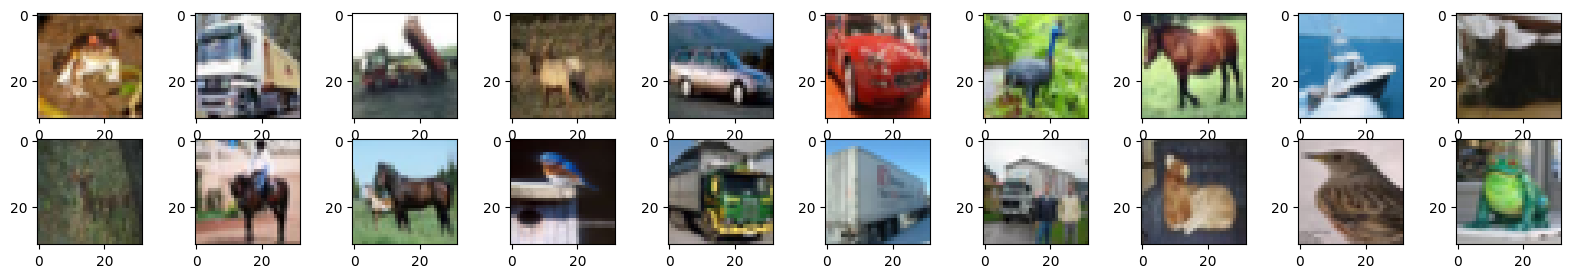

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 3))
for c in range(20):
    plt.subplot(2, 10, c+1)
    plt.imshow(X_train[c])
    print(y_train[c], end=' ')

In [14]:
X_train.shape, y_train.shape

(torch.Size([50000, 32, 32, 3]), torch.Size([50000]))

In [15]:
X_train = X_train.permute(0, 3, 1, 2)
X_test = X_test.permute(0, 3, 1, 2)

In [30]:
X_train.shape, X_test.shape

(torch.Size([50000, 3, 32, 32]), torch.Size([10000, 3, 32, 32]))

In [42]:
class LeNet5(torch.nn.Module):
    def __init__(self, activation, pooling='avg', conv_size=5, use_batch_norm=False):
        super(LeNet5, self).__init__()

        self.conv_size = conv_size
        self.use_batch_norm = use_batch_norm
        self.activation_name = activation
        self.pooling_type = pooling

        activation_classes = {
            'tanh': torch.nn.Tanh,
            'relu': torch.nn.ReLU,
            'elu': torch.nn.ELU,
            'leaky_relu': torch.nn.LeakyReLU,
            'sigmoid': torch.nn.Sigmoid,
            'hardtanh': torch.nn.Hardtanh,
            'relu6': torch.nn.ReLU6,
            'selu': torch.nn.SELU,
            'celu': torch.nn.CELU,
            'gelu': torch.nn.GELU,
            'prelu': torch.nn.PReLU,
            'rrelu': torch.nn.RReLU,
            'logsigmoid': torch.nn.LogSigmoid,
            'softplus': torch.nn.Softplus,
            'softshrink': torch.nn.Softshrink,
            'softsign': torch.nn.Softsign,
            'tanhshrink': torch.nn.Tanhshrink,
            'hardshrink': torch.nn.Hardshrink,
        }

        if activation in activation_classes:
            act_class = activation_classes[activation]
        else:
            raise ValueError(f"Активация {activation} не поддерживается")

        self.act1 = act_class()
        self.act2 = act_class()
        self.act3 = act_class()
        self.act4 = act_class()
        
        if pooling == 'avg':
            self.pool = torch.nn.AvgPool2d(kernel_size=2, stride=2)
        elif pooling == 'max':
            self.pool = torch.nn.MaxPool2d(kernel_size=2, stride=2)

        if conv_size == 5:
            self.conv1 = torch.nn.Conv2d(3, 6, kernel_size=5, padding=0)
            self.conv2 = torch.nn.Conv2d(6, 16, kernel_size=5, padding=0)
            self.fc_input_size = 5 * 5 * 16
        elif conv_size == 3:
            self.conv1_1 = torch.nn.Conv2d(3, 6, kernel_size=3, padding=1)
            self.conv1_2 = torch.nn.Conv2d(6, 6, kernel_size=3, padding=1)
            self.conv2_1 = torch.nn.Conv2d(6, 16, kernel_size=3, padding=1)
            self.conv2_2 = torch.nn.Conv2d(16, 16, kernel_size=3, padding=1)
            self.fc_input_size = 8 * 8 * 16
        else:
            raise NotImplementedError

        self.bn1 = torch.nn.BatchNorm2d(6)
        self.bn2 = torch.nn.BatchNorm2d(16)

        self.fc1 = torch.nn.Linear(self.fc_input_size, 120)
        self.fc2 = torch.nn.Linear(120, 84)
        self.fc3 = torch.nn.Linear(84, 10)

    def forward(self, x):
        if self.conv_size == 5:
            x = self.conv1(x)
            x = self.act1(x)
            if self.use_batch_norm:
                x = self.bn1(x)
            x = self.pool(x)
            
            x = self.conv2(x)
            x = self.act2(x)
            if self.use_batch_norm:
                x = self.bn2(x)
            x = self.pool(x)
            
        elif self.conv_size == 3:
            x = self.conv1_1(x)
            x = self.act1(x)
            x = self.conv1_2(x)
            x = self.act1(x)
            if self.use_batch_norm:
                x = self.bn1(x)
            x = self.pool(x)
            
            x = self.conv2_1(x)
            x = self.act2(x)
            x = self.conv2_2(x)
            x = self.act2(x)
            if self.use_batch_norm:
                x = self.bn2(x)
            x = self.pool(x)

        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.act3(x)
        x = self.fc2(x)
        x = self.act4(x)
        x = self.fc3(x)
        
        return x

In [45]:
def train(net, X_train, X_test, y_train, y_test):
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    net = net.to(device)
    loss = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

    batch_size = 100
    test_accuracy_his = []
    loss_his = []

    X_train = X_train.cpu()
    y_train = y_train.cpu()
    X_test = X_test.to(device)
    y_test = y_test.to(device)

    n_samples = len(X_train)

    for epoch in range(500):
        order = np.random.permutation(n_samples)
        
        for batch_ind in range(0, n_samples, batch_size):
            optimizer.zero_grad()
            net.train()

            batch_indexes = order[batch_ind:min(batch_ind + batch_size, n_samples)]
            
            X_batch = X_train[batch_indexes].to(device)
            y_batch = y_train[batch_indexes].to(device)

            preds = net.forward(X_batch)
            loss_value = loss(preds, y_batch)
            
            loss_value.backward()
            optimizer.step()

        net.eval()
        with torch.no_grad():
            test_preds = net(X_test)
            test_loss = loss(test_preds, y_test).item()
            accuracy = (test_preds.argmax(dim=1) == y_test).float().mean().item()
        
        loss_his.append(test_loss)
        test_accuracy_his.append(accuracy)

        if epoch % 50 == 0:
            print(f"Epoch {epoch}, Accuracy: {accuracy:.4f}, Test Loss: {test_loss:.4f}")

    return test_accuracy_his, loss_his